# Treino do Modelo NumPy (DNN com implementação própria)
Este notebook treina uma Deep Neural Network implementada de raiz em NumPy para classificação multi-classe de texto (Human vs. AI).

In [1]:
import pandas as pd
import numpy as np
import pickle
import re
import sys
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '.')))

from src.neuralnet import NeuralNetwork
from src.layers import DenseLayer, DropoutLayer
from src.activation import ReLUActivation, SoftmaxActivation
from src.losses import CategoricalCrossEntropy

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregamento e Pré-processamento dos Dados

In [2]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.strip()

df = pd.read_csv("data/dataset-training.csv", sep=";")

CLASSES_OFICIAIS = ["Human", "Google", "Meta", "OpenAI", "Anthropic"]
df = df[df["Label"].isin(CLASSES_OFICIAIS)].copy()
df["clean_text"] = df["Text"].apply(clean_text)

print(f"Total de exemplos válidos: {len(df)}")
print("\nDistribuição das classes:")
print(df["Label"].value_counts())

Total de exemplos válidos: 5000

Distribuição das classes:
Label
Anthropic    1000
Google       1000
OpenAI       1000
Meta         1000
Human        1000
Name: count, dtype: int64


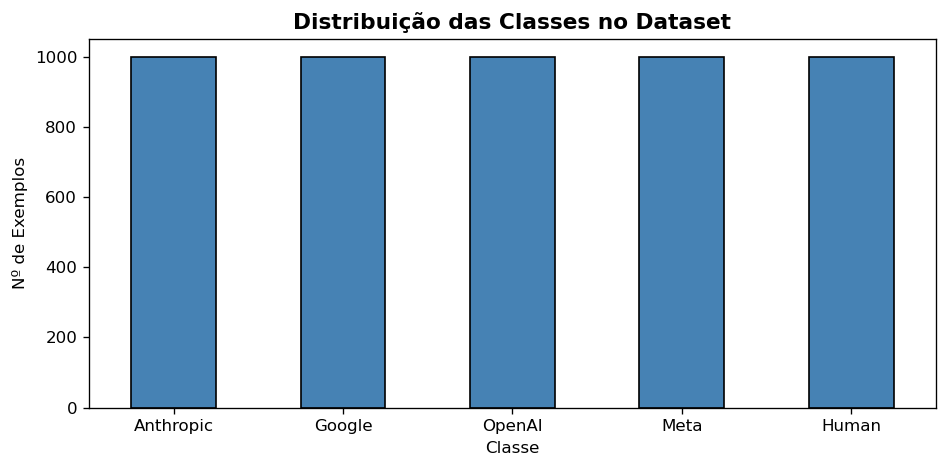

In [3]:
# Visualizar distribuição das classes
fig, ax = plt.subplots(figsize=(8, 4))
df["Label"].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title("Distribuição das Classes no Dataset", fontsize=13, fontweight='bold')
ax.set_xlabel("Classe")
ax.set_ylabel("Nº de Exemplos")
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig("plots/numpy_class_distribution.png", bbox_inches='tight')
plt.show()

## 2. Criação das Features (TF-IDF) e Divisão Train/Test

In [4]:
le = LabelEncoder()
le.fit(CLASSES_OFICIAIS)
labels_idx = le.transform(df["Label"])

vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df["clean_text"]).toarray()

# Divisão treino/teste (80/20 estratificada)
X_train, X_test, y_train_idx, y_test_idx = train_test_split(
    X, labels_idx, test_size=0.20, random_state=RANDOM_SEED, stratify=labels_idx
)

# One-Hot Encoding
def to_onehot(idx, n_classes):
    oh = np.zeros((len(idx), n_classes))
    oh[np.arange(len(idx)), idx] = 1
    return oh

n_classes = len(le.classes_)
y_train = to_onehot(y_train_idx, n_classes)
y_test  = to_onehot(y_test_idx,  n_classes)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test:  {y_test.shape}")
print(f"Classes: {le.classes_}")

X_train: (4000, 5000) | X_test: (1000, 5000)
y_train: (4000, 5) | y_test:  (1000, 5)
Classes: ['Anthropic' 'Google' 'Human' 'Meta' 'OpenAI']


## 3. Definição e Treino da DNN

In [5]:
# Histórico de treino para análise
train_losses = []
train_accs   = []

class NeuralNetworkTracked(NeuralNetwork):
    """Extensão da NeuralNetwork que guarda histórico de loss e accuracy."""
    def fit(self, X, y):
        from src.metrics import accuracy_score as acc_fn
        n_samples = X.shape[0]
        for epoch in range(1, self.epochs + 1):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X[indices[start:end]]
                y_batch = y[indices[start:end]]
                output = self.forward_propagation(X_batch, training=True)
                error  = self.loss_func.derivative(y_batch, output)
                self.backward_propagation(error)
            preds = self.forward_propagation(X, training=False)
            loss  = self.loss_func.loss(y, preds)
            acc   = acc_fn(y, preds)
            train_losses.append(loss)
            train_accs.append(acc)
            if epoch % 5 == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{self.epochs} | Loss: {loss:.4f} | Acc: {acc:.4f}")

net = NeuralNetworkTracked(epochs=50, batch_size=16, learning_rate=0.01, momentum=0.9)
net.add(DenseLayer(256, input_shape=(X_train.shape[1],)))
net.add(ReLUActivation())
net.add(DropoutLayer(drop_rate=0.4))
net.add(DenseLayer(128))
net.add(ReLUActivation())
net.add(DropoutLayer(drop_rate=0.3))
net.add(DenseLayer(64))
net.add(ReLUActivation())
net.add(DropoutLayer(drop_rate=0.2))
net.add(DenseLayer(n_classes))
net.add(SoftmaxActivation())

print("A treinar o modelo NumPy DNN...")
net.fit(X_train, y_train)
print("\nTreino concluído!")

A treinar o modelo NumPy DNN...
Epoch   1/50 | Loss: 1.6068 | Acc: 0.2352
Epoch   5/50 | Loss: 1.5874 | Acc: 0.3980
Epoch  10/50 | Loss: 1.4988 | Acc: 0.5300
Epoch  15/50 | Loss: 1.2242 | Acc: 0.6607
Epoch  20/50 | Loss: 0.9274 | Acc: 0.7045
Epoch  25/50 | Loss: 0.7195 | Acc: 0.7630
Epoch  30/50 | Loss: 0.5419 | Acc: 0.8490
Epoch  35/50 | Loss: 0.3972 | Acc: 0.8895
Epoch  40/50 | Loss: 0.2974 | Acc: 0.9213
Epoch  45/50 | Loss: 0.2028 | Acc: 0.9515
Epoch  50/50 | Loss: 0.1487 | Acc: 0.9673

Treino concluído!


## 4. Curvas de Treino

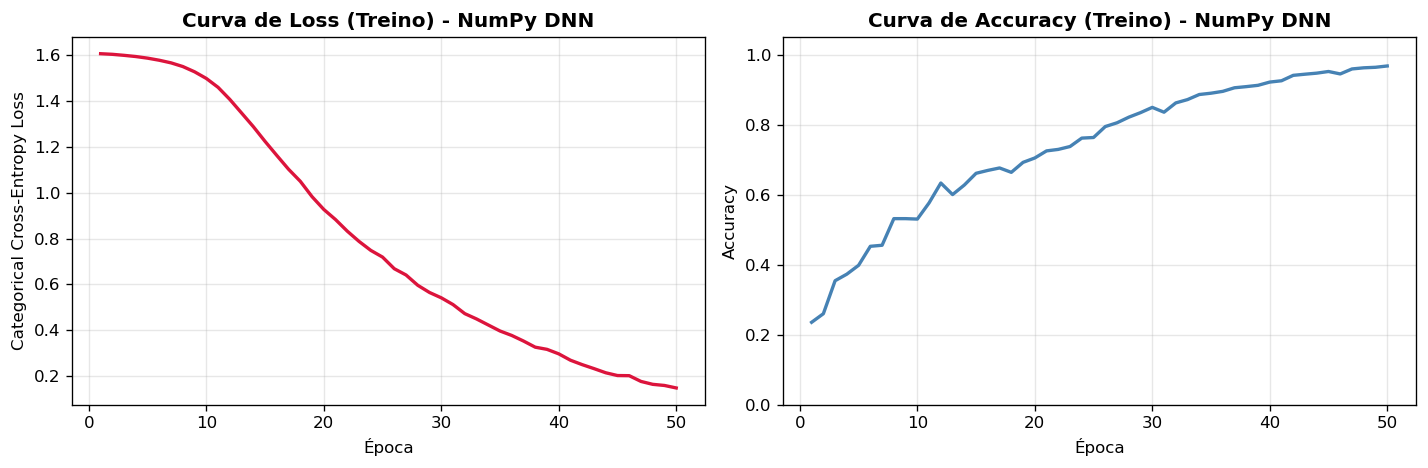

In [6]:
os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, color='crimson', linewidth=2)
axes[0].set_title("Curva de Loss (Treino) - NumPy DNN", fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Categorical Cross-Entropy Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accs, color='steelblue', linewidth=2)
axes[1].set_title("Curva de Accuracy (Treino) - NumPy DNN", fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/numpy_training_curves.png", bbox_inches='tight')
plt.show()

## 5. Avaliação no Conjunto de Teste

In [7]:
# Inferência no teste
preds_probs = net.predict(X_test)
preds_idx   = np.argmax(preds_probs, axis=1)

# Loss no teste
test_loss = CategoricalCrossEntropy().loss(y_test, preds_probs)

# Lista de índices de todas as classes (garante que métricas incluem classes ausentes no teste)
all_class_indices = list(range(len(le.classes_)))

# Métricas — labels=all_class_indices força avaliação sobre todas as 5 classes
test_acc        = accuracy_score(y_test_idx, preds_idx)
macro_f1        = f1_score(y_test_idx, preds_idx, average="macro",    labels=all_class_indices, zero_division=0)
weighted_f1     = f1_score(y_test_idx, preds_idx, average="weighted", labels=all_class_indices, zero_division=0)
macro_precision = precision_score(y_test_idx, preds_idx, average="macro", labels=all_class_indices, zero_division=0)
macro_recall    = recall_score(y_test_idx, preds_idx, average="macro",    labels=all_class_indices, zero_division=0)
bal_acc         = balanced_accuracy_score(y_test_idx, preds_idx)

print("=" * 55)
print("         AVALIAÇÃO NO CONJUNTO DE TESTE - NumPy DNN")
print("=" * 55)
print(f"  Test Loss              : {test_loss:.4f}")
print(f"  Test Accuracy          : {test_acc:.4f}")
print(f"  Balanced Accuracy      : {bal_acc:.4f}")
print(f"  Macro F1-Score         : {macro_f1:.4f}")
print(f"  Weighted F1-Score      : {weighted_f1:.4f}")
print(f"  Macro Precision        : {macro_precision:.4f}")
print(f"  Macro Recall           : {macro_recall:.4f}")
print("=" * 55)

print("\nRelatório por Classe:")
print(classification_report(
    y_test_idx, preds_idx,
    labels=all_class_indices,
    target_names=le.classes_,
    zero_division=0
))

         AVALIAÇÃO NO CONJUNTO DE TESTE - NumPy DNN
  Test Loss              : 0.7094
  Test Accuracy          : 0.7470
  Balanced Accuracy      : 0.7470
  Macro F1-Score         : 0.7414
  Weighted F1-Score      : 0.7414
  Macro Precision        : 0.7400
  Macro Recall           : 0.7470

Relatório por Classe:
              precision    recall  f1-score   support

   Anthropic       0.74      0.78      0.76       200
      Google       0.68      0.66      0.67       200
       Human       0.84      0.91      0.87       200
        Meta       0.80      0.88      0.84       200
      OpenAI       0.64      0.52      0.57       200

    accuracy                           0.75      1000
   macro avg       0.74      0.75      0.74      1000
weighted avg       0.74      0.75      0.74      1000



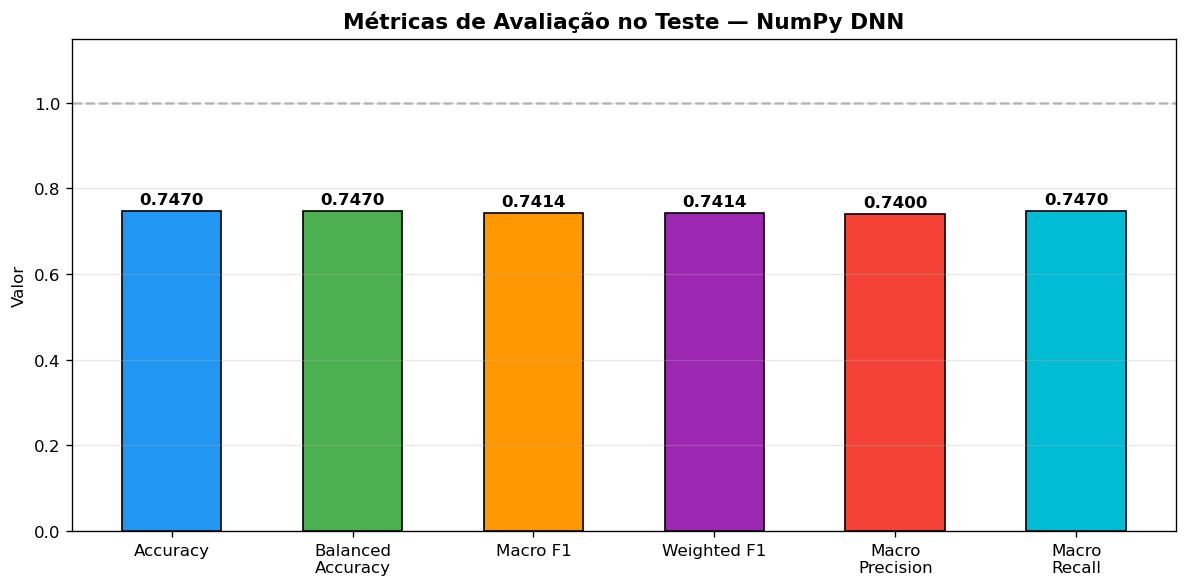

In [8]:
# Gráfico de barras das métricas
metrics_names  = ["Accuracy", "Balanced\nAccuracy", "Macro F1", "Weighted F1", "Macro\nPrecision", "Macro\nRecall"]
metrics_values = [test_acc, bal_acc, macro_f1, weighted_f1, macro_precision, macro_recall]
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='black', width=0.55)
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title("Métricas de Avaliação no Teste — NumPy DNN", fontsize=13, fontweight='bold')
ax.set_ylabel("Valor")
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/numpy_test_metrics.png", bbox_inches='tight')
plt.show()

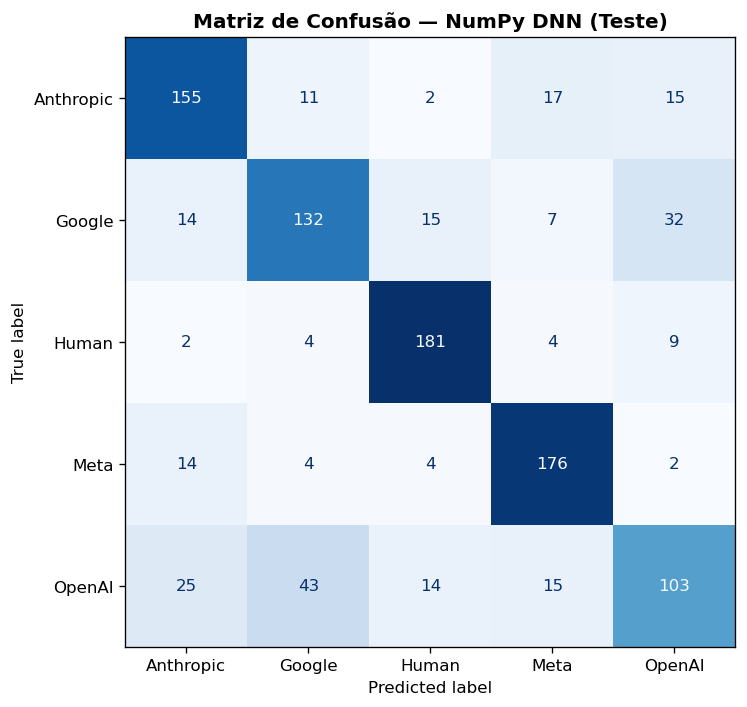

In [9]:
# Matriz de Confusão — forçar todas as classes com labels=all_class_indices
cm = confusion_matrix(y_test_idx, preds_idx, labels=all_class_indices)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title("Matriz de Confusão — NumPy DNN (Teste)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/numpy_confusion_matrix.png", bbox_inches='tight')
plt.show()

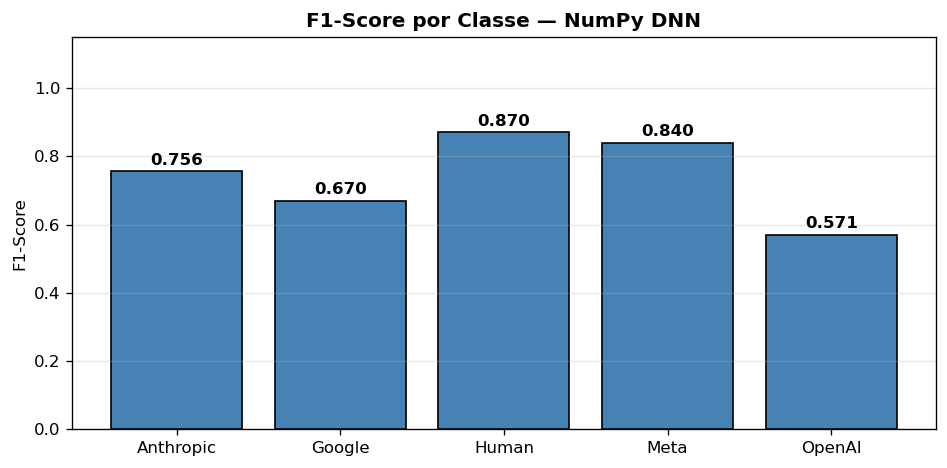

In [10]:
# F1-Score por classe — labels garante 5 valores mesmo que alguma classe não apareça nas preds
f1_per_class = f1_score(y_test_idx, preds_idx, average=None, labels=all_class_indices, zero_division=0)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(le.classes_, f1_per_class, color='steelblue', edgecolor='black')
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title("F1-Score por Classe — NumPy DNN", fontsize=12, fontweight='bold')
ax.set_ylabel("F1-Score")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/numpy_f1_per_class.png", bbox_inches='tight')
plt.show()

## 6. Guardar Modelo e Artefactos

In [11]:
# Guardar artefactos e métricas
numpy_metrics = {
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "balanced_accuracy": bal_acc,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "train_losses": train_losses,
    "train_accs": train_accs
}

with open("modelo_numpy_artefactos.pkl", "wb") as f:
    pickle.dump({
        "model": net,
        "vectorizer": vectorizer,
        "label_encoder": le,
        "metrics": numpy_metrics
    }, f)

print("Artefactos NumPy guardados com sucesso!")
print(f"\nResumo Final — NumPy DNN:")
print(f"  Macro F1   : {macro_f1:.4f}")
print(f"  Accuracy   : {test_acc:.4f}")
print(f"  Bal. Acc   : {bal_acc:.4f}")

Artefactos NumPy guardados com sucesso!

Resumo Final — NumPy DNN:
  Macro F1   : 0.7414
  Accuracy   : 0.7470
  Bal. Acc   : 0.7470
